In [14]:
# import libraries
import numpy as np

from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
# To be able to see the plots in the browser
%matplotlib inline

In [3]:
def redshift_distribution(z):
    norm = 1.
    z_o = 0.5
    beta = 1.5
    dndz = norm * np.power((z/z_o),2) * np.exp(-np.power((z/z_o),beta))
    return dndz

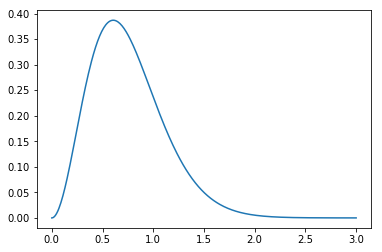

In [10]:
z_try = np.linspace(0.,3.0,300)
dndz = redshift_distribution(z_try)
plt.plot(z_try,redshift_distribution(z_try))

In [11]:
# normalized cumulative function
dndz_cum = np.cumsum(dndz)
dndz_cum_norm = dndz_cum / np.amax(dndz_cum)

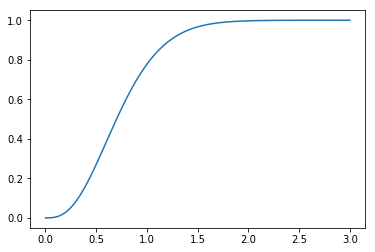

In [12]:
plt.plot(z_try,dndz_cum_norm)

In [15]:
# intepolation function
dndz_interp = interp1d(z_try,dndz_cum_norm)


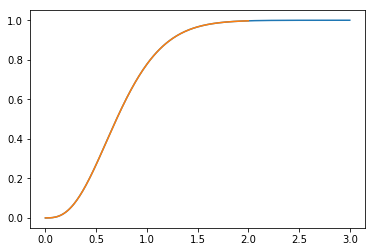

In [16]:
z2 = np.linspace (0.,2.0,1000)
plt.plot(z_try,dndz_cum_norm)
plt.plot(z2,dndz_interp(z2))

In [18]:
# inverse normalized cumulative function
dzdn_interp = interp1d(dndz_cum_norm,z_try)

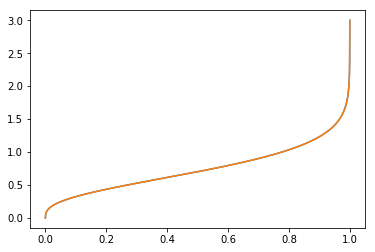

In [19]:
u2 = np.linspace(0.0,1.0,1000)
plt.plot(dndz_cum_norm,z_try)
plt.plot(u2,dzdn_interp(u2))

In [20]:
# generate catalogue
n = 100000
random_values = np.random.random(n)

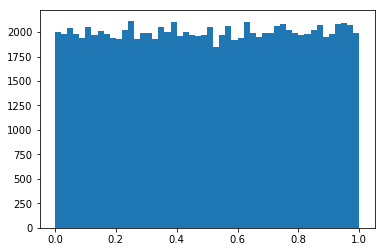

In [23]:
plt.hist(random_values,bins=50);

In [33]:
%%time
# generate the redshifts
z_values = dzdn_interp(random_values)

CPU times: user 5.91 ms, sys: 1.87 ms, total: 7.78 ms
Wall time: 5.87 ms


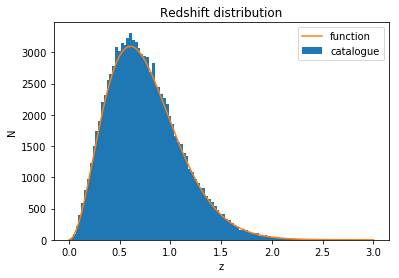

In [32]:
plt.hist(z_values,bins=100,label='catalogue');
plt.plot(z_try,8.0e+3*redshift_distribution(z_try),label='function')
plt.xlabel('z')
plt.ylabel('N')
plt.title('Redshift distribution')
plt.legend()

In [34]:
# 2d distribution

In [35]:
import pandas as pd

In [36]:
cat = pd.read_csv('/Users/fjc/6944.csv.bz2',sep=",", comment='#', na_values=r'\N')

In [37]:
cat.shape

(26453897, 3)

In [38]:
cat.columns

Index(['g_mag', 'r_mag', 'z_cgal'], dtype='object')

In [39]:
print (np.amin(cat['g_mag']))
print (np.amax(cat['g_mag']))
print (np.amin(cat['r_mag']))
print (np.amax(cat['r_mag']))


15.447000000000001
27.926
14.39
25.694000000000003


In [40]:
cat['gr'] = cat['g_mag'] - cat['r_mag']

In [41]:
print (np.amin(cat['gr']))
print (np.amax(cat['gr']))


-0.1620000000000026
2.2319999999999958


AttributeError: module 'matplotlib.pyplot' has no attribute 'colormap'

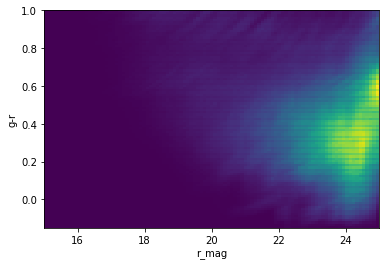

In [44]:
p1,p2,p3,p4 = plt.hist2d(cat['r_mag'],cat['gr'],
                        bins=(np.linspace(15.0,25.0,100),np.linspace(-0.15,1.0,100)),
                         alpha=1.);
plt.xlabel('r_mag')
plt.ylabel('g-r')

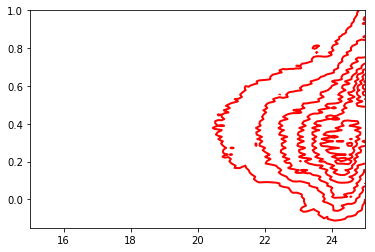

In [45]:
plt.contour(p1.transpose(),extent=[p2[0],p2[-1],p3.min(),p3.max()],linewidths=2,colors='r')

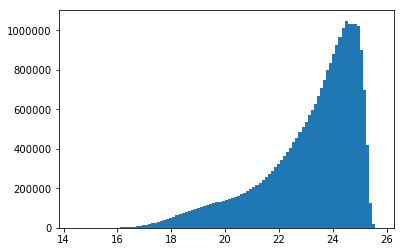

In [48]:
r_min = np.amin(cat['r_mag'])
r_max = np.amax(cat['r_mag'])

plt.hist(cat['r_mag'],bins=np.linspace(r_min,r_max,100));



In [49]:
r_hist,r_bins = np.histogram(cat['r_mag'],bins=np.linspace(r_min,r_max,300))

In [52]:
r_cum = np.cumsum(r_hist)
r_cum_norm = r_cum / r_cum[-1]

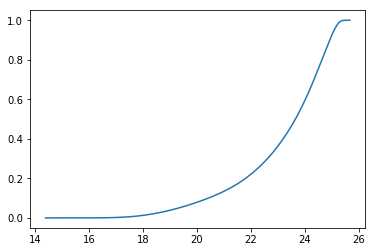

In [53]:
plt.plot(r_bins[:-1],r_cum_norm)

In [59]:
r_func = interp1d(r_cum_norm,r_bins[:-1])
n_func = interp1d(r_bins[:-1],r_cum_norm)

In [55]:
n_obj = 100000


In [56]:
random_values = np.random.random(n_obj)

In [57]:
r_mag_new = r_func(random_values)

In [58]:
# r sample with two randoms
n_try = 1000000
random1 = np.random.random(n_try)
random2 = np.random.random(n_try)

r_val = random1*(r_max-r_min)+r_min

In [67]:
print (r_bins[-2])

25.656193979933114


In [64]:
r_val2 = np.where(r_val < r_bins[-2],r_val,r_bins[-2])

In [68]:
print (np.amin(r_val2))
print (np.amax(r_val2))

14.390010430240029
25.656193979933114


In [65]:
r_val_choose = np.where(random2 < n_func(r_val2),r_val2,-1.)

In [69]:
print (np.amin(r_val_choose))
print (np.amax(r_val_choose))

-1.0
25.656193979933114


In [70]:
r_val_choose[r_val_choose > 0.].shape

(226695,)

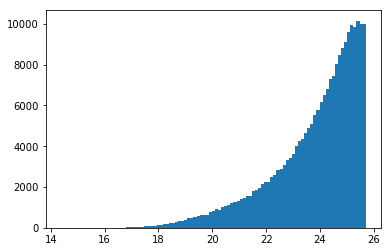

In [73]:
plt.hist(r_val_choose[r_val_choose > 0.],bins=np.linspace(r_min,r_max,100));

In [ ]:
MICE2_22p5_i = np.array(MICE2_grizy[MICE2_grizy['des_i_AM'] <22.5]['des_i_AM'])

MICE2_22p5_ie = np.array(MICE2_grizy[MICE2_grizy['des_i_AM'] <22.5]['log10_des_i_AM_err'])

k021,k022,k023,k024 = plt.hist2d(MICE2_22p5_i,MICE2_22p5_ie,
                         bins=(np.linspace(19.0,23.0,50),np.linspace(-2.5,-0.5,80)),alpha=1.0);
plt.xlabel('i')
plt.ylabel('log10(i_err)')
plt.title('MICE2 i<22.5')

In [ ]:
k001,k002,k003,k004 = plt.hist2d(MICE2_22p5_g,MICE2_22p5_ge,
                         bins=(np.linspace(20.0,25.0,50),np.linspace(-2.5,-0.5,80)),alpha=1.0);
plt.xlabel('g')
plt.ylabel('log10(g_err)')
plt.title('MICE2 i<22.5')
plt.colorbar()

In [ ]:
plt.contour(h001.transpose(),extent=[h002[0],h002[-1],h003.min(),h003.max()],linewidths=2,colors='r')
plt.contour(k001.transpose(),extent=[k002[0],k002[-1],k003.min(),k003.max()],linewidths=2,colors='b',linestyles='dashed')
plt.xlabel('g')
plt.ylabel('log10(g_err)')
plt.title('red:DES blue:MICE2')

In [1]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from astropy.cosmology import FlatLambdaCDM

# To be able to see the plots in the browser
%matplotlib inline

In [2]:
# sql qury to cosmohub
# SELECT lmhalo 
# FROM micecatv2_0_view 
# where z_cgal between 0.90 and 1.10 and flag_central = 0 and dec_gal > 70.

In [3]:
halo_cat = pd.read_csv('/Users/fjc/6936.csv.bz2', sep=",", comment='#', na_values=r'\N')

In [4]:
halo_cat.columns

Index(['lmhalo'], dtype='object')

In [5]:
halo_cat.shape

(3280928, 1)

In [6]:
lm_min = np.amin(halo_cat['lmhalo'])
lm_max = np.amax(halo_cat['lmhalo'])
print ('lm_min=',lm_min,' lmmax=',lm_max)

lm_min= 11.0101  lmmax= 14.5902


In [7]:
lm_bins = np.linspace(lm_min,lm_max,101)
#bins
print (lm_bins.shape)

(101,)


In [8]:
lm_hist, lm_edges = np.histogram(halo_cat['lmhalo'], bins=lm_bins)

In [9]:
print (lm_hist.shape)
print (lm_edges.shape)

(100,)
(101,)


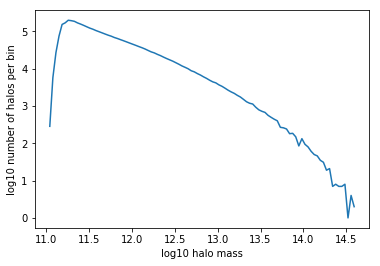

In [10]:
plt.plot(lm_edges[1:],np.log10(lm_hist))
plt.xlabel('log10 halo mass')
plt.ylabel('log10 number of halos per bin')

In [11]:
lm_hist_error = np.sqrt(lm_hist)

In [12]:
# compute the volume
cosmo = FlatLambdaCDM(H0=100., Om0=0.25, Ob0=0.049, Tcmb0=2.725)

In [13]:
vol09 = cosmo.comoving_volume(0.9)  # volume inside z=0.9
vol11 = cosmo.comoving_volume(1.1)  # volume inside z=1.1

volume = vol11 - vol09
volume.value

25810418926.93183

In [14]:
area = np.pi/2*(1.-np.sin(70.*np.pi/180.))
area_deg = area * 180.*180. / np.pi/np.pi
print ('area =',area,'sr ',area_deg,'deg2')

area = 0.09473060974812211 sr  310.98224722161973 deg2


In [15]:
vol = volume.value/(4.*np.pi)*area
print ('volume =',vol)

volume = 194569840.2376309


In [16]:
delta_lm = lm_edges[1] - lm_edges[0]

In [17]:
print (vol)
print (delta_lm)

194569840.2376309
0.035800999999999306


In [18]:
lm_abun = lm_hist / vol / delta_lm

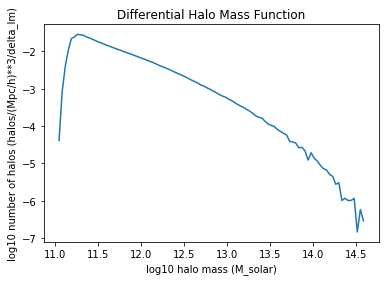

In [19]:
plt.plot(lm_edges[1:],np.log10(lm_abun))
plt.xlabel('log10 halo mass (M_solar)')
plt.ylabel('log10 number of halos (halos/(Mpc/h)**3/delta_lm)')
plt.title('Differential Halo Mass Function')

In [20]:
# cumulative

lm_hist_cum = np.flipud(np.cumsum(np.flipud(lm_hist)))

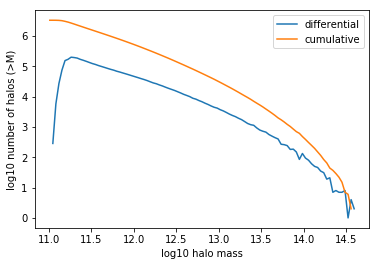

In [21]:
plt.plot(lm_edges[1:],np.log10(lm_hist),label='differential')
plt.plot(lm_edges[:-1],np.log10(lm_hist_cum),label='cumulative')
plt.xlabel('log10 halo mass')
plt.ylabel('log10 number of halos (>M)')
plt.legend()

In [22]:
lm_abun_cum = lm_hist_cum / vol 

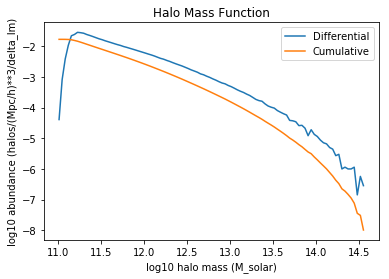

In [23]:
plt.plot(lm_edges[:-1],np.log10(lm_abun),label='Differential')
plt.plot(lm_edges[:-1],np.log10(lm_abun_cum),label='Cumulative')
plt.xlabel('log10 halo mass (M_solar)')
plt.ylabel('log10 abundance (halos/(Mpc/h)**3/delta_lm)')
plt.title('Halo Mass Function')
plt.legend()

In [24]:
# compare with theory
import hmf

In [25]:
hmf_z10_Tinker = hmf.MassFunction(cosmo_model=cosmo,n=0.95,sigma_8=0.8,z=1.0,transfer_model='EH',
                           Mmin=lm_min,Mmax=lm_max,dlog10m=0.01,delta_h=200.0,delta_wrt='mean',delta_c=1.686)

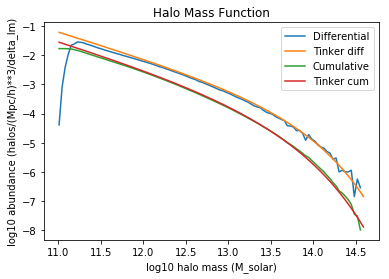

In [26]:
plt.plot(lm_edges[:-1],np.log10(lm_abun),label='Differential')
plt.plot(np.log10(hmf_z10_Tinker.m),np.log10(hmf_z10_Tinker.dndlog10m),label='Tinker diff')
plt.plot(lm_edges[:-1],np.log10(lm_abun_cum),label='Cumulative')
plt.plot(np.log10(hmf_z10_Tinker.m),np.log10(hmf_z10_Tinker.ngtm),label='Tinker cum')
plt.xlabel('log10 halo mass (M_solar)')
plt.ylabel('log10 abundance (halos/(Mpc/h)**3/delta_lm)')
plt.title('Halo Mass Function')
plt.legend()

In [27]:
#np.log10(hmf_z10_Tinker.ngtm)


In [28]:
#hmf_z10_Tinker.parameter_info()
#hmf_z10_Tinker.parameter_values